# 第60课 · 与 PyTorch 对答案——autograd 的 grad_fn 计算图 vs 你手写的 Value 引擎

**目标**：同图两边求梯度——PyTorch `grad_fn` vs 手写 `Value`，数值应对齐。

> **验证课**：对答案建立信心，再放心用 `loss.backward()`。

🔗 **Aurora 连接**：Month 2–5 的所有模型训练都调用 `.backward()`；本节确立的等价性是后续用 torch 替换手写 Value 图的信心基础。具体入口：Aurora ML 引擎（`src/aurora/ml/`，计划中模块）训练循环里的每个 `loss.backward()` 都依赖此机制。

← **上一课**　[L59 · PyTorch Tensor 基础](L59_tensor_basics.ipynb)

> 上节课学习了 **PyTorch Tensor 基础**：与 NumPy 互转、device、`requires_grad`。  
> 本课将探讨 **autograd 机制**。

## 本课剧情：PyTorch 怎么"记住"你做了什么运算？

在 L54–L56 中我们自己实现了 `Value` 类——每个节点存着 `_backward` 闭包和 `_prev` 集合，手动建图。PyTorch 做的事完全一样，只是规模更大、速度更快。

**核心机制**：每个 `requires_grad=True` 的 Tensor 自动挂一个 `grad_fn`（梯度函数），记录"我是怎么算出来的"：

```python
a = torch.tensor(2.0, requires_grad=True)   # 叶节点，grad_fn=None
b = torch.tensor(3.0, requires_grad=True)   # 叶节点
c = a * b                                    # c.grad_fn = MulBackward0
d = c + a                                    # d.grad_fn = AddBackward0
```

图长这样：
```
a ──┬──[×]──► c ──[+]──► d
b ──┘         a ──────────┘
```

**叶节点 vs 非叶节点**：

| 类型 | 定义 | `.grad` 规则 |
|---|---|---|
| 叶节点 | `requires_grad=True` 且非运算结果 | backward后自动填入 `.grad` |
| 非叶节点 | 由运算创建 | `.grad=None`（除非 `retain_grad()`）|

**为什么非叶节点默认不存梯度**：中间激活值可能有数百万个，全存会爆显存。只保留叶节点（参数）的梯度，够训练用了。

本节任务：验证 `L = 2*a*b + 3*b` 对 `a, b` 的梯度，并理解 `detach()`、`retain_grad()`、梯度累积。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import torch
import numpy as np

## 1. 计算图：`requires_grad=True` 与叶 / 非叶节点（non-leaf node）

当张量带 `requires_grad=True` 时，每次运算会生成一个 `grad_fn` 并把结果节点挂在图上。
**叶节点（leaf tensor）**：由用户直接创建，`is_leaf == True`，梯度会在 `.backward()` 后存入 `.grad`。
**非叶节点**：由运算派生，`is_leaf == False`，默认不保留梯度（`.grad` 为 `None`），需要 `retain_grad()` 才能查看。

```
a (leaf)  b (leaf)
  \          /
   c = a * b   <- c.grad_fn = MulBackward0, c.is_leaf = False
       |
   L = c + a   <- L.grad_fn = AddBackward0
```

In [3]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
c = a * b
L = c + a

print('a.is_leaf:', a.is_leaf)   # True
print('c.is_leaf:', c.is_leaf)   # False
print('c.grad_fn:', c.grad_fn)   # MulBackward0
print('L.grad_fn:', L.grad_fn)   # AddBackward0

a.is_leaf: True
c.is_leaf: False
c.grad_fn: <MulBackward0 object at 0x1300881f0>
L.grad_fn: <AddBackward0 object at 0x1300881f0>


### 深入理解：为什么要分叶/非叶？

你可能会问："为什么不把每个张量的梯度都存下来？"

**显存的现实**：一个现代深度学习模型有数百万甚至数十亿个参数。如果你有 12 层神经网络，每层有 100 万个激活值，那仅仅保存这些中间激活值的梯度就需要 12×100 万 = 1200 万个浮点数。在 GPU 上，这可能是几十 GB 的显存。

但训练时我们只需要更新**参数**（叶节点）。激活值（非叶节点）的梯度只是中间计算过程，用完就可以丢弃。这就是为什么 PyTorch 默认不保留非叶节点梯度。

**初始梯度值**：在 `backward()` 前，`.grad` 是 `None`（不是 0）。PyTorch 只在第一次 `backward()` 时为叶节点**创建** `.grad` 张量并填入梯度值。如果再做一次 `backward()`，新梯度会**加到**已有的 `.grad` 上——这就是"梯度累积"。

**边界情况**：
```python
a = torch.tensor(2.0, requires_grad=True)
c = a * 2  # c 是非叶节点（由运算产生）
d = torch.tensor(3.0, requires_grad=True)  # 即使在这一行创建，d 仍是叶节点
```
关键是：**only "直接创建的 + requires_grad=True"才是叶子，运算结果都是非叶子**。

**具体例子**：一个 3 层 MLP 中哪些梯度保留？
```
input → [Linear 1] → a1 → [ReLU] → b1 → [Linear 2] → a2 → [ReLU] → b2 → [Linear 3] → logit → Loss
   叶       参数           非叶          参数           非叶          参数           非叶       |
                                                                                              ↓
                                                                                            backward
```
- **保留**：3 个 Linear 层的权重和偏置（参数，叶节点）
- **丢弃**：a1, b1, a2, b2, logit 的梯度（都是中间激活值）
- **如果需要看中间梯度**（比如调试梯度消失），用 `retain_grad()`——但代价是内存增加


## 2. `.detach()` 与 `.grad` 的存储规则

`.detach()` 返回一个与原张量**共享数据但切断梯度流**的新张量。运算不再被记录到计算图。
常见用途：

1. **调试/打印**：把中间张量转为 numpy 而不影响梯度链
   ```python
   y = model(x)  # y 在图上
   print(y.detach().numpy())  # 安全打印，不切断梯度
   ```

2. **固定某条路径**：GAN 中生成器和判别器的梯度路径分离
   ```python
   fake = generator(z)
   # 判别器评估 fake，但梯度不回流到生成器
   d_loss = discriminator(fake.detach())
   d_loss.backward()  # 只更新判别器参数
   ```

3. **停止梯度**：某些参数在这一步不更新
   ```python
   # EMA（指数移动平均）更新：target_net 冻结
   target_y = target_net(x).detach()
   loss = (model(x) - target_y) ** 2
   loss.backward()  # 只更新 model，不更新 target_net
   ```

**对比**：`.grad` 只有叶节点自动保留；非叶节点必须在 `backward()` 前调 `retain_grad()`，否则 `.grad` 一直是 `None`。

**重要**：`detach()` 和 `retain_grad()` 解决不同问题：
- `detach()` 是说"从这里开始不再记录梯度"
- `retain_grad()` 是说"记录过梯度，但默认会丢，我想保留这个梯度值"

In [4]:
x = torch.tensor(1.0, requires_grad=True)
y = x * 2          # 非叶节点
y.retain_grad()    # 开启非叶梯度保留
L2 = y * 3
L2.backward()

print('x.grad:', x.grad)   # 6.0  (dL2/dx = 3*2)
print('y.grad:', y.grad)   # 3.0  (dL2/dy = 3)

# detach 演示
y_np = y.detach().numpy()   # 不影响图
print('y_np (detach):', y_np)

x.grad: tensor(6.)
y.grad: tensor(3.)
y_np (detach): 2.0


## 3. 梯度累积（gradient accumulation）与 `zero_grad()`

每次调用 `.backward()`，PyTorch 会把新梯度**加到** `.grad` 上，而不是覆盖。
这是有意设计（支持梯度累积训练技巧），但在标准训练循环中会导致梯度错误地叠加。

规范做法：
```python
for batch in dataloader:
    optimizer.zero_grad()   # 清零上一步残留
    loss = model(batch)
    loss.backward()
    optimizer.step()
```

手写 `Value` 引擎同理：每次反向前需手动把所有节点的 `.grad` 归零。

In [5]:
w = torch.tensor(1.0, requires_grad=True)

# 两次 backward，不清零
for i in range(2):
    L3 = w * 3.0
    L3.backward()
    print(f'第 {i+1} 次 backward 后 w.grad = {w.grad}')  # 3.0, 6.0

# 清零后再做
w.grad.zero_()
L3 = w * 3.0
L3.backward()
print('zero_grad 后 w.grad =', w.grad)  # 3.0

第 1 次 backward 后 w.grad = 3.0
第 2 次 backward 后 w.grad = 6.0
zero_grad 后 w.grad = tensor(3.)


### 梯度累积的实际场景：显存不足的分批训练

梯度累积被"有意设计"，最常见的用途是应对显存限制。

**场景**：假设我们要训练一个大模型，实际需要的 batch_size=128，但 GPU 显存只够跑 batch_size=32。

**不用梯度累积的做法**（错误）：
```python
for batch in dataloader:
    loss = model(batch)
    loss.backward()
    optimizer.step()
    # 这时 batch_size 只有 32，梯度是 32 个样本的平均值，不是 128 的
```

**用梯度累积的做法**（正确）：
```python
for batch_idx, batch in enumerate(dataloader):
    loss = model(batch)
    loss.backward()  # 梯度加到 .grad 上
    
    if (batch_idx + 1) % 4 == 0:  # 累积 4 个 batch（4×32=128）
        optimizer.step()
        optimizer.zero_grad()  # 清零准备下一轮累积
```

这样，参数更新用的梯度是 128 个样本的平均，但显存只消耗 32 个样本的。这是一个显存 ↔ 精度的权衡。

**标准训练循环中为什么要 `zero_grad()`**：如果不累积梯度，每步更新前都要清零，否则新旧梯度混合，模型学不对。

## 3.5 `retain_graph=True` 与 `retain_grad()`：两个正交的 API

这两个 API 名字像，但保留的对象和时机完全不同。理解它们需要知道 PyTorch backward 的三个阶段：

| 阶段 | 发生时间 | 保存的是什么 |
|---|---|---|
| **前向传播** | `z = w * x` 后 | `grad_fn` 里的 `saved_tensors`（如 w 和 x 的值，为了求导用） |
| **反向传播** | `loss.backward()` 执行中 | 逐个计算每个节点的梯度，存在 `.grad` 属性 |
| **清理** | `backward()` 返回后 | 默认释放 `saved_tensors`（节省显存），非叶节点 `.grad` 丢弃 |

**`retain_grad()` 的作用**：告诉 PyTorch"反向传播完后，**保留这个非叶节点的 .grad 值**"。
- 作用**时机**：必须在 `backward()` 之前调
- 保留的**对象**：该节点的 `.grad` 张量（梯度值本身）
- **代价**：微小（只是不释放一个张量引用）

**`backward(retain_graph=True)` 的作用**：告诉 PyTorch"反向传播完后，**保留计算图和 saved_tensors**"。
- 作用**时机**：在 `backward()` 的参数里指定
- 保留的**对象**：整个计算图的 DAG 结构和 `grad_fn` 里的 `saved_tensors`（包括前向传播保存的中间值）
- **代价**：显著（这些 saved_tensors 可能很大，比如一个 batch 的激活值）

**什么是 `saved_tensors`**：反向求导需要前向的中间值。比如 `c = a * b` 求 `∂c/∂a = b`，就需要在反向时用到 `b` 的值。PyTorch 在前向时把这些"被求导需要的值"保存在 `grad_fn.saved_tensors` 里。默认 backward 后释放以节省显存。

**典型场景：多任务学习中同时调用两个 loss 的 backward**

```python
# 场景：encoder 被两个 head 共享
shared = encoder(x)       # shared.grad_fn = ...
head1_out = head1(shared)  # 需要 shared 的值来求导
head2_out = head2(shared)  # 同一个 shared

loss1 = criterion(head1_out, y1)
loss2 = criterion(head2_out, y2)

# 第一次 backward：保留计算图（因为 loss2 也要用）
loss1.backward(retain_graph=True)

# 第二次 backward：不再保留，图释放
loss2.backward()
```

如果省略 `retain_graph=True`，第一次 backward 后图被释放，第二次会报 RuntimeError。

**同时使用两个 API**：
```python
shared = encoder(x)
head1_out = head1(shared)
head2_out = head2(shared)

# 假设 shared 是非叶节点
shared.retain_grad()       # ← 保留 shared.grad 值

loss1 = criterion(head1_out, y1)
loss2 = criterion(head2_out, y2)

loss1.backward(retain_graph=True)
print(shared.grad)         # ✅ 可以看到 shared 对 loss1 的梯度

loss2.backward()
print(shared.grad)         # ✅ 还能看到最终的梯度（因为 retain_grad）
```

**总结**：
- `retain_grad()` → 保留中间梯度值（调试用）
- `retain_graph=True` → 保留计算图以便多次 backward（多 loss 场景）
- 两者是"正交"的：一个保留值，一个保留图，互不影响，可以同时用

In [6]:
# === 演示 retain_graph=True ===

w = torch.tensor(2.0, requires_grad=True)
x_fixed = torch.tensor(3.0)

# 同一前向传播，产生两个 loss
z = w * x_fixed           # z = 6.0
loss1 = z * z             # L1 = z²,  dL1/dw = 2z·x = 36.0
loss2 = z + 1.0           # L2 = z+1, dL2/dw = x   =  3.0

# 第一次 backward：保留图
loss1.backward(retain_graph=True)
print(f'loss1.backward(retain_graph=True) → w.grad = {w.grad.item()}')
assert abs(w.grad.item() - 36.0) < 1e-6, '期望 dL1/dw = 36.0'

# 第二次 backward：不再保留，图在此释放
w.grad.zero_()
loss2.backward()
print(f'loss2.backward()                 → w.grad = {w.grad.item()}')
assert abs(w.grad.item() - 3.0) < 1e-6, '期望 dL2/dw = 3.0'

# 对比：不加 retain_graph，提前释放图 → 第二次 backward 报 RuntimeError
print()
w2 = torch.tensor(2.0, requires_grad=True)
z2 = w2 * x_fixed
loss1b = z2 * z2
loss2b = z2 + 1.0
loss1b.backward()  # retain_graph=False（默认），图在此释放
try:
    loss2b.backward()
    print('错误：此处应抛出 RuntimeError')
except RuntimeError as e:
    print(f'✅ 预期 RuntimeError（图已释放）：{str(e)[:90]}')

print('\n结论：retain_graph=True 保留图；retain_grad() 保留非叶 .grad 值。两者正交，可同时使用。')


loss1.backward(retain_graph=True) → w.grad = 36.0
loss2.backward()                 → w.grad = 3.0

✅ 预期 RuntimeError（图已释放）：Trying to backward through the graph a second time (or directly access saved tensors after

结论：retain_graph=True 保留图；retain_grad() 保留非叶 .grad 值。两者正交，可同时使用。


## 4. ✏️ 实现 `verify_gradients()`

**任务**：对 `L = 2*a*b + 3*b`（`a=2.0, b=3.0`），验证自动梯度和手算梯度一致。

**手算结果**：
```
∂L/∂a = 2b = 6.0
∂L/∂b = 2a + 3 = 7.0
```

**运算符重载的细节**（不用担心）：
- `2 * a` 时，Python int 2 不知道怎么和 Tensor 相乘，会调用 `a.__rmul__(2)`（反向乘法）
- PyTorch 的 Tensor 实现了 `__rmul__`，返回 `2.0 * a`（还是 Tensor）
- `2*a*b` 会先算 `2*a`（结果是 Tensor），再乘 `b`，一切都在计算图上
- 最后 `L` 是个标量 Tensor（shape=[]），可以直接 `L.backward()`

**实现要点**：

| 步骤 | 操作 | 注意 |
|---|---|---|
| 1 | `a = torch.tensor(2.0, requires_grad=True)`，`b` 同理 | 必须 `requires_grad=True` |
| 2 | `L = 2*a*b + 3*b` | 每步都是 Tensor 运算，自动建图 |
| 3 | `L.backward()` | 标量才能直接 backward()；多维需要传入梯度权重 |
| 4 | `assert abs(a.grad - 6.0) < 1e-6` | 检验 a 的梯度 |
| 5 | `assert abs(b.grad - 7.0) < 1e-6` | 检验 b 的梯度 |
| 6 | `return a.grad.item(), b.grad.item()` | 下方检查格靠返回值验证 |

**验收标准**：函数运行无错，返回 `(6.0, 7.0)`，打印 `a.grad=6.0, b.grad=7.0`。

### 背景：多变量函数的偏导数

在进行 `verify_gradients()` 之前，快速复习一下偏导数的含义。

**偏导数是什么？** 它回答这个问题："当我只改变某个变量，其他都冻结，这个函数怎么变化？"

比如 `L = 2*a*b + 3*b`：
- `∂L/∂a` = "如果只改 a，L 怎么变？把 b 看成常数"
  - L = 2a·b + 3·b（b 冻结）
  - 对 a 求导 → `∂L/∂a = 2b`
  
- `∂L/∂b` = "如果只改 b，L 怎么变？把 a 看成常数"
  - L = 2a·b + 3·b（a 冻结）
  - 对 b 求导 → `∂L/∂b = 2a + 3`

**计算方法**：对每个变量分别求导，把其他变量当常数
```
L = 2*a*b + 3*b

∂L/∂a：把 b 看常数
  = 2·b + 0（3*b 对 a 的导数是 0）
  = 2b

∂L/∂b：把 a 看常数
  = 2·a + 3（2*a 是常数，乘以 b 的导数 1）
  = 2a + 3
```

**为什么这很重要？** 在神经网络中，参数（权重 w、偏置 b）需要的梯度就是这样的偏导数：`∂loss/∂w`，`∂loss/∂b`。

In [7]:
def verify_gradients():
    # ✏️ TODO: a=2.0, b=3.0（requires_grad=True）；L = 2*a*b + 3*b；L.backward()；
    #          assert 两个梯度后 return a.grad.item(), b.grad.item()
    raise NotImplementedError("TODO: 创建 a=2.0, b=3.0，L=2*a*b+3*b，backward，assert 后返回两个梯度")

try:
    print(verify_gradients())
except (NotImplementedError, TypeError) as e:
    print(f'⬜ 尚未实现：{e}')

⬜ 尚未实现：TODO: 创建 a=2.0, b=3.0，L=2*a*b+3*b，backward，assert 后返回两个梯度


In [8]:
# --- 检查：调用学生实现的 verify_gradients() ---
import torch

try:
    result = verify_gradients()
except (NotImplementedError, TypeError):
    result = None

if result is None:
    print("⬜ 请先实现 verify_gradients()（记得 return a.grad.item(), b.grad.item()），再运行此格")
    print("   提示：L = 2ab + 3b → dL/da = 2b = 6.0，dL/db = 2a + 3 = 7.0")
else:
    da, db = result
    assert abs(da - 6.0) < 1e-4, f'dL/da 应为 6.0（=2b），实际 {da}'
    assert abs(db - 7.0) < 1e-4, f'dL/db 应为 7.0（=2a+3），实际 {db}'
    print(f'✅ dL/da = {da} | dL/db = {db} — 与解析值一致')

⬜ 请先实现 verify_gradients()（记得 return a.grad.item(), b.grad.item()），再运行此格
   提示：L = 2ab + 3b → dL/da = 2b = 6.0，dL/db = 2a + 3 = 7.0


## 5. 参数实验：自制 Value vs torch 对 `L = tanh(w*x + b)` 的梯度误差

**实验参数**：`w` 在 `[-2, -1, 0, 1, 2]` 上扫描，`x=1.0, b=0.5` 固定。

**链式法则推导**：
```
z = w*x + b
L = tanh(z)

∂L/∂w = (∂L/∂z) · (∂z/∂w)
      = (1 - tanh²(z)) · x    ← 链式法则

其中：
  - ∂z/∂w = x（w 对 w 的偏导数是 x）
  - ∂L/∂z = d(tanh)/dz = 1 - tanh²(z)（tanh 的导数）
```

**tanh 导数的两种常见形式**（都是对的）：
1. `1 - tanh²(z)` ← 我们用的这个
2. `sech²(z) = 1/cosh²(z)` ← 双曲线函数表达

**为什么 tanh 导数是 1 - tanh²？** 从定义推导：
```python
# tanh(z) = (e^z - e^-z) / (e^z + e^-z)
# 求导后化简得：d(tanh)/dz = 1 - tanh²(z)

import math
z = 0.5
tanh_z = math.tanh(z)
derivative_direct = 1 - tanh_z**2
print(f"tanh({z}) = {tanh_z}")
print(f"导数 1 - tanh²(z) = {derivative_direct}")
# 在 z=0.5 时导数 ≈ 0.75
```

**预期现象**：
- torch autograd 和手写 Value 的梯度在 1e-6 精度内吻合
- tanh 饱和区（`|w|` 大时 L 饱和）梯度趋近 0，两者差值也趋近 0
- 图中两条曲线完全重叠，误差曲线贴近 x 轴

最大误差 atol: 2.9127579015408855e-08


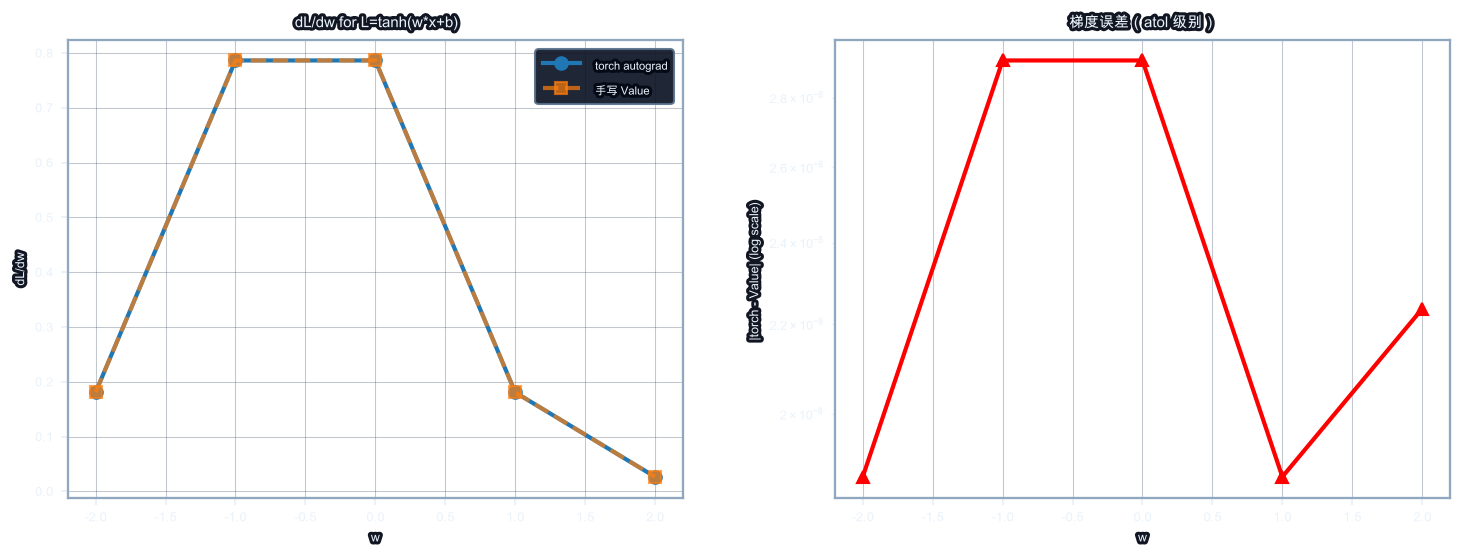

In [9]:
import matplotlib.pyplot as plt
import math

# ---- 手写 Value（最小实现，与 L56_backward_pass.ipynb 一致）----
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _back():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _back
        return out

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _back():
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _back
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _back():
            self.grad += (1 - t**2) * out.grad
        out._backward = _back
        return out

    def backward(self):
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for c in v._prev: build(c)
                topo.append(v)
        build(self)
        self.grad = 1.0
        for v in reversed(topo): v._backward()

# ---- 对比实验 ----
ws = [-2.0, -1.0, 0.0, 1.0, 2.0]
x_val, b_val = 1.0, 0.5

grads_torch, grads_value, errors = [], [], []

for w_val in ws:
    # torch
    wt = torch.tensor(w_val, requires_grad=True)
    xt = torch.tensor(x_val)
    bt = torch.tensor(b_val)
    Lt = torch.tanh(wt * xt + bt)
    Lt.backward()
    gt = wt.grad.item()
    grads_torch.append(gt)

    # Value
    wv = Value(w_val)
    xv = Value(x_val)
    bv = Value(b_val)
    Lv = (wv * xv + bv).tanh()
    Lv.backward()
    gv = wv.grad
    grads_value.append(gv)

    errors.append(abs(gt - gv))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(ws, grads_torch, 'o-', label='torch autograd', linewidth=2)
ax1.plot(ws, grads_value, 's--', label='手写 Value', linewidth=2, alpha=0.7)
ax1.set_xlabel('w')
ax1.set_ylabel('dL/dw')
ax1.set_title('dL/dw for L=tanh(w*x+b)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.semilogy(ws, [max(e, 1e-20) for e in errors], 'r^-', linewidth=2)
ax2.set_xlabel('w')
ax2.set_ylabel('|torch - Value| (log scale)')
ax2.set_title('梯度误差（atol 级别）')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('最大误差 atol:', max(errors))

## 本课收束

`verify_gradients()` 返回了 `dL/da=6.0, dL/db=7.0`，与手算解析导数完全一致；参数实验进一步确认 torch autograd 与手写 `Value` 引擎在 1e-6 精度内吻合。
本节确认：PyTorch `autograd` 的计算图遍历、叶节点梯度存储、以及 `zero_grad()` 规范，与 `L56_backward_pass.ipynb` 的纯 Python 实现在数学上等价。
这份等价性是后续用 torch 替换手写引擎的信心基础——Aurora ML 引擎（`src/aurora/ml/`，计划中模块）的训练循环将直接调用 `loss.backward()`。
下一节（L61）用 `nn.Module` 重建 L57 的 MLP 结构：`nn.Parameter` 注册、`parameters()` / `state_dict()` 参数管理与模型保存。

> **retain_graph vs retain_grad**：`retain_grad()` 保留非叶节点的 `.grad` 值（本节演示）；`loss.backward(retain_graph=True)` 保留计算图以便多次调用 `backward()`（多任务学习等场景会用到，见 3.5 节）。

## ✏️ 白板挑战：autograd 机制手推（目标 10 分钟）

盖上屏幕，纸上推导：

**问 1**：`L = 2*a*b + 3*b`，`a=2.0, b=3.0`。手算 `∂L/∂a` 和 `∂L/∂b`。  
（∂L/∂a=2b=6.0，∂L/∂b=2a+3=2×2+3=7.0）

**问 2**：为什么非叶节点的 `.grad` 默认是 `None`？用 `retain_grad()` 解决后有什么代价？  
（省显存；保留中间梯度会使内存增加，等同于保存所有激活值）

**问 3**：同一个 Tensor 做了两次 `backward()`（没有 `retain_graph=True`），会发生什么？  
（计算图在第一次 backward 后被释放；第二次会抛出 RuntimeError）

**问 4**：`w.grad.zero_()` 和 `w.grad = None` 有什么区别？  
（zero_() 保留 grad Tensor 对象，置零；grad=None 删除梯度引用；后者在 optimizer 里更常见）

**问 5**：`x.detach()` 后做运算，梯度还会流回 `x` 吗？为什么需要 detach？  
（不会流回；detach 切断梯度链，常用于将 logit 传给 loss 计算但不想影响某些参数）

推导完成后运行下方格验证。

In [10]:
# ✏️ 对答案格
import torch

# 问1：手算梯度验证
a_q = torch.tensor(2.0, requires_grad=True)
b_q = torch.tensor(3.0, requires_grad=True)
L_q = 2*a_q*b_q + 3*b_q
L_q.backward()
assert abs(a_q.grad.item() - 6.0) < 1e-6, f"a.grad={a_q.grad.item()}"
assert abs(b_q.grad.item() - 7.0) < 1e-6, f"b.grad={b_q.grad.item()}"
print(f"Q1 ✅  L=2ab+3b: ∂L/∂a={a_q.grad.item():.1f}=2b=6, ∂L/∂b={b_q.grad.item():.1f}=2a+3=7")

# 问2：非叶节点grad=None，retain_grad保留
x_q = torch.tensor(2.0, requires_grad=True)
y_q = x_q * 3    # 非叶
y_q.retain_grad()
z_q = y_q ** 2
z_q.backward()
assert x_q.grad is not None      # 叶节点有grad
assert y_q.grad is not None      # retain_grad保留了中间grad
print(f"Q2 ✅  retain_grad后非叶grad={y_q.grad.item():.1f}，叶grad={x_q.grad.item():.1f}")

# 问3：二次backward报错
x2 = torch.tensor(1.0, requires_grad=True)
y2 = x2 ** 2
y2.backward()
try:
    y2.backward()
    print("Q3 ❌  应该报错但没有")
except RuntimeError as e:
    print(f"Q3 ✅  第二次backward报RuntimeError（图已释放）: {str(e)[:50]}...")

# 问4：zero_() vs grad=None
w_q = torch.tensor(1.0, requires_grad=True)
(w_q * 2).backward()
grad_obj_before = id(w_q.grad)
w_q.grad.zero_()
assert id(w_q.grad) == grad_obj_before   # 同一对象
w_q.grad = None
assert w_q.grad is None
print(f"Q4 ✅  zero_()保留grad对象，grad=None删除引用")

# 问5：detach切断梯度
x5 = torch.tensor(3.0, requires_grad=True)
xd = x5.detach()
y5 = xd * 2
# y5没有grad_fn
assert y5.grad_fn is None
print(f"Q5 ✅  x.detach()后: y=xd*2的grad_fn={y5.grad_fn}（None，梯度不会流回x）")
print("\n🎉 autograd 机制白板挑战通过！")

Q1 ✅  L=2ab+3b: ∂L/∂a=6.0=2b=6, ∂L/∂b=7.0=2a+3=7
Q2 ✅  retain_grad后非叶grad=12.0，叶grad=36.0
Q3 ✅  第二次backward报RuntimeError（图已释放）: Trying to backward through the graph a second time...
Q4 ✅  zero_()保留grad对象，grad=None删除引用
Q5 ✅  x.detach()后: y=xd*2的grad_fn=None（None，梯度不会流回x）

🎉 autograd 机制白板挑战通过！


In [ ]:
# ✏️ 本课自评
l60_review = {
    "leaf_vs_nonleaf":         None,  # 理解叶/非叶节点区别，为什么非叶.grad=None？True/False
    "verify_gradients_impl":   None,  # verify_gradients()实现正确，梯度断言通过？True/False
    "detach_understood":       None,  # 理解detach()切断梯度流的场景和原因？True/False
    "grad_accumulation":       None,  # 理解不清零时多次backward梯度累积问题？True/False
    "whiteboard_passed":       None,  # 白板挑战5道手推全部完成？True/False
}

unfilled = [k for k, v in l60_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l60_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L60 全部通关！进入 L61：nn.Module 实战')

In [ ]:
# Aurora 连接：推理端 vs 训练端的分工
# aurora.llm.KVCache 是纯 numpy 的推理组件——推理不需要梯度，所以不需要计算图（从零原则）；
# 训练端（src/aurora/ml/，计划中模块）则将直接依赖本课验证过的 torch autograd。
from aurora.llm.kvcache import KVCache

print("aurora.llm.kvcache.KVCache:", KVCache)
print("KVCache 基类:", [b.__name__ for b in KVCache.__bases__], "→ 纯 numpy 实现，无梯度、无计算图")
print("训练端（计划中的 src/aurora/ml/）将用 loss.backward() —— 正是本课验证的机制")

---

→ **下一课**　[L61 · nn.Module 实战](L61_pytorch_nn.ipynb)

> 下节课将学习 **nn.Module 实战**：Linear / ReLU / Sequential，参数管理与模型保存。